## 5. Speech Emotion Classification Using LSTM
### Objective
Build an **LSTM-based speech emotion classification model** using any suitable **open-source audio dataset**.

### Task
1. Choose an open-source dataset for speech emotion classification.
2. Study the dataset structure, labels, and class distribution.
3. Preprocess the audio into sequential features suitable for LSTM, such as:
  - MFCC sequences
  - Log-Mel spectrogram frame sequences
  - Chroma or other temporal acoustic features
4. Design and train a **Long Short-Term Memory (LSTM)** model for emotion classification.
5. Evaluate the model on test data and report the results.

I have Chosen **"Toronto emotional speech set (TESS)"**

### Reason:
- Contains exactly 400 samples for each of its seven emotion categories, avoiding training bias.
- Features a total of 2,800 distinct audio file utterances.
- Uses a uniform carrier phrase ("Say the word [target]") across all recordings

In [1]:
# download dataset
!mkdir -p tess
!curl -L -o tess/tess_dataset.zip https://www.kaggle.com/api/v1/datasets/download/ejlok1/toronto-emotional-speech-set-tess

!unzip -q tess/tess_dataset.zip -d tess/

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  427M  100  427M    0     0   139M      0  0:00:03  0:00:03 --:--:--  177M


In [2]:
! rm -rf "/content/tess/tess toronto emotional speech set data"

In [3]:
import os
import pandas as pd

def describe_dataset(dataset_path):
    emotions = []
    files = []

    for root, _, filenames in os.walk(dataset_path):
        for file in filenames:
            if file.endswith(".wav"):
                emotion = file.split("_")[-1].replace(".wav", "")
                emotions.append(emotion)
                files.append(os.path.join(root, file))

    df = pd.DataFrame({"File": files, "Emotion": emotions})

    print(f"Total Audio Files: {len(df)}")
    print(f"Total Emotions: {df['Emotion'].nunique()}")
    print(f"Emotion Classes: {sorted(df['Emotion'].unique())}")
    print("Class Distribution")
    print(df["Emotion"].value_counts().sort_index())
    return df

In [4]:
df = describe_dataset("/content/tess/TESS Toronto emotional speech set data")

Total Audio Files: 2800
Total Emotions: 7
Emotion Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'ps', 'sad']
Class Distribution
Emotion
angry      400
disgust    400
fear       400
happy      400
neutral    400
ps         400
sad        400
Name: count, dtype: int64


In [5]:
import numpy as np
import librosa

class AudioPreprocessor:
    def __init__(self, sr=16000, duration=2.0, n_mfcc=13, n_fft=2048, hop_length=512):
      self.sr = sr
      self.max_samples = int(sr * duration)
      self.n_mfcc = n_mfcc
      self.n_fft = n_fft
      self.hop_length = hop_length

    def load_audio(self, path):
      audio, _ = librosa.load(path, sr=self.sr)
      return audio

    def pad_or_truncate(self, audio):
      if len(audio) < self.max_samples:
        audio = np.pad(audio, (0, self.max_samples - len(audio)))
      else:
        audio = audio[:self.max_samples]
      return audio

    def normalize(self, audio):
      return librosa.util.normalize(audio)

    def extract_mfcc(self, audio):
      mfcc = librosa.feature.mfcc(y=audio, sr=self.sr, n_mfcc=self.n_mfcc, n_fft=self.n_fft, hop_length=self.hop_length)
      return mfcc.T

    def extract_features(self, path):
      audio = self.load_audio(path)
      audio = self.pad_or_truncate(audio)
      audio = self.normalize(audio)
      return self.extract_mfcc(audio)

    def preprocess_dataset(self, df):
        X, y = [], []

        for _, row in df.iterrows():
            X.append(self.extract_features(row["File"]))
            y.append(row["Emotion"])

        return np.array(X), np.array(y)


In [8]:
# check process pipeline
preprocessor = AudioPreprocessor()

X, y = preprocessor.preprocess_dataset(df)

print(X.shape)
print(y.shape)

(2800, 63, 13)
(2800,)


In [10]:
import torch
from torch.utils.data import Dataset

# datasetclass wrapper
class AudioDataset(Dataset):
    def __init__(self, dataframe, preprocessor):
        self.dataframe = dataframe.reset_index(drop=True)
        self.preprocessor = preprocessor
        self.label_map = {label: idx for idx, label in enumerate(sorted(dataframe["Emotion"].unique()))}
        self.num_classes = len(self.label_map)
    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        audio_path = self.dataframe.loc[idx, "File"]
        label = self.dataframe.loc[idx, "Emotion"]

        features = self.preprocessor.extract_features(audio_path)

        features = torch.tensor(features, dtype=torch.float32)
        label = torch.tensor(self.label_map[label], dtype=torch.long)

        return features, label

In [30]:
preprocessor = AudioPreprocessor()

dataset = AudioDataset(df, preprocessor)
features, label = dataset[0]
print(features.shape)
print(label)

torch.Size([63, 13])
tensor(1)


In [11]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Emotion"], random_state=42)

train_dataset = AudioDataset(train_df, preprocessor)
test_dataset = AudioDataset(test_df, preprocessor)
# data loader with custom wrapper
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [12]:
import torch
import torch.nn as nn

class LSTMEmotionClassifier(nn.Module):
    def __init__(self, input_size=13, hidden_size=128, num_layers=2, num_classes=7, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, num_classes)
    # LSTM frwd pass
    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)
        x = hidden[-1]
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [13]:
# check model structure
model = LSTMEmotionClassifier()
print(model)

LSTMEmotionClassifier(
  (lstm): LSTM(13, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=7, bias=True)
)


In [14]:
import torch.optim as optim

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMEmotionClassifier().to(device)
# loss fn and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 20

In [15]:
def train(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0
    predictions = []
    labels = []
    # training loop
    for features, target in loader:
        features = features.to(device)
        target = target.to(device)
        optimizer.zero_grad()

        outputs = model(features)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predictions.extend(outputs.argmax(dim=1).cpu().numpy())
        labels.extend(target.cpu().numpy())

    loss = running_loss / len(loader)
    accuracy = accuracy_score(labels, predictions)
    return loss, accuracy

In [16]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0
    predictions = []
    labels = []
    # validation loop
    with torch.no_grad():
        for features, target in loader:
            features = features.to(device)
            target = target.to(device)
            outputs = model(features)
            loss = criterion(outputs, target)

            running_loss += loss.item()
            predictions.extend(outputs.argmax(dim=1).cpu().numpy())
            labels.extend(target.cpu().numpy())

    loss = running_loss / len(loader)
    accuracy = accuracy_score(labels, predictions)
    return loss, accuracy, labels, predictions

In [17]:
def fit(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(epochs):
        train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch+1:02}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    return history

In [20]:
history = fit(model, train_loader, test_loader, criterion, optimizer, epochs=10, device=device)

Epoch 01/10 | Train Loss: 0.0838 | Train Acc: 0.9799 | Val Loss: 0.1753 | Val Acc: 0.9500
Epoch 02/10 | Train Loss: 0.0835 | Train Acc: 0.9741 | Val Loss: 0.0492 | Val Acc: 0.9875
Epoch 03/10 | Train Loss: 0.0447 | Train Acc: 0.9866 | Val Loss: 0.0489 | Val Acc: 0.9893
Epoch 04/10 | Train Loss: 0.0575 | Train Acc: 0.9839 | Val Loss: 0.1134 | Val Acc: 0.9768
Epoch 05/10 | Train Loss: 0.0441 | Train Acc: 0.9879 | Val Loss: 0.0663 | Val Acc: 0.9839
Epoch 06/10 | Train Loss: 0.0279 | Train Acc: 0.9933 | Val Loss: 0.3777 | Val Acc: 0.9179
Epoch 07/10 | Train Loss: 0.0504 | Train Acc: 0.9866 | Val Loss: 0.0632 | Val Acc: 0.9875
Epoch 08/10 | Train Loss: 0.0154 | Train Acc: 0.9969 | Val Loss: 0.0724 | Val Acc: 0.9875
Epoch 09/10 | Train Loss: 0.0097 | Train Acc: 0.9973 | Val Loss: 0.0983 | Val Acc: 0.9893
Epoch 10/10 | Train Loss: 0.0221 | Train Acc: 0.9929 | Val Loss: 0.0866 | Val Acc: 0.9839


In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
def plot(history):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].plot(history["train_loss"], label="Train")
    ax[0].plot(history["val_loss"], label="Validation")
    ax[0].set_title("Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    ax[1].plot(history["train_acc"], label="Train")
    ax[1].plot(history["val_acc"], label="Validation")
    ax[1].set_title("Accuracy")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

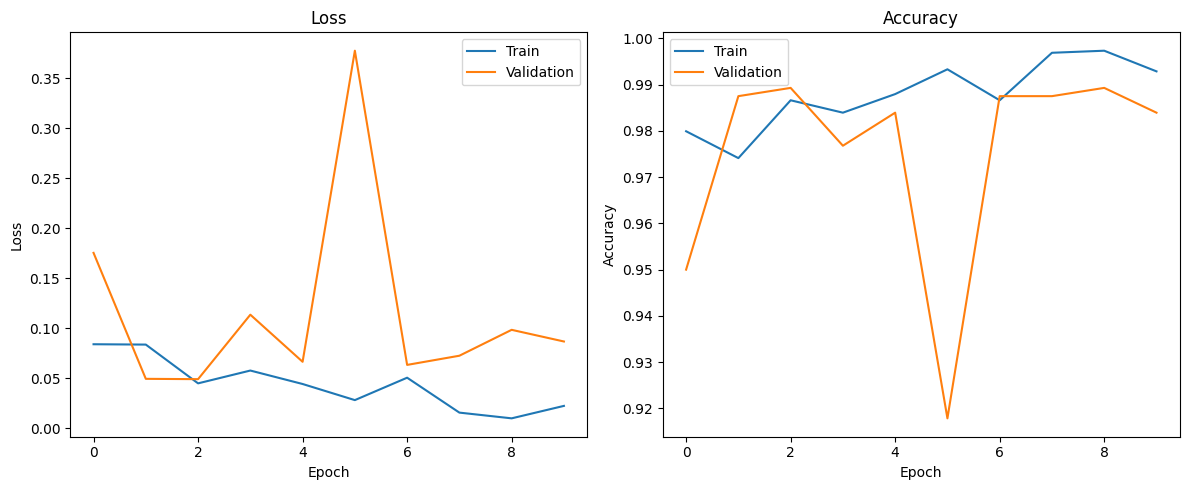

In [23]:
plot(history)

Accuracy : 0.9839
Precision: 0.9843
Recall   : 0.9839
F1 Score : 0.9839
              precision    recall  f1-score   support

       angry       0.99      1.00      0.99        80
     disgust       0.95      1.00      0.98        80
        fear       1.00      0.97      0.99        80
       happy       0.99      1.00      0.99        80
     neutral       1.00      0.97      0.99        80
          ps       0.99      0.95      0.97        80
         sad       0.98      0.99      0.98        80

    accuracy                           0.98       560
   macro avg       0.98      0.98      0.98       560
weighted avg       0.98      0.98      0.98       560



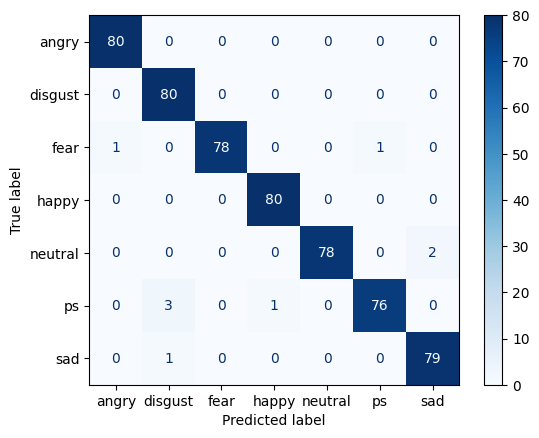

In [24]:
_, _, labels, predictions = validate(model, test_loader, criterion, device)

print(f"Accuracy : {accuracy_score(labels, predictions):.4f}")
print(f"Precision: {precision_score(labels, predictions, average='weighted'):.4f}")
print(f"Recall   : {recall_score(labels, predictions, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(labels, predictions, average='weighted'):.4f}")

print(classification_report(labels, predictions, target_names=["angry","disgust","fear","happy","neutral","ps","sad"]))

ConfusionMatrixDisplay.from_predictions(labels, predictions, display_labels=["angry","disgust","fear","happy","neutral","ps","sad"], cmap="Blues")
plt.show()

In [31]:
import random
import librosa
import librosa.display
import matplotlib.pyplot as plt

def visualize_predictions(model, dataset, device, label_map):
    model.eval()
    idx_to_label = {v: k for k, v in label_map.items()}

    correct = []
    wrong = []

    with torch.no_grad():
        for idx in range(len(dataset)):
            features, label = dataset[idx]

            output = model(features.unsqueeze(0).to(device))
            pred = output.argmax(dim=1).item()

            if pred == label.item() and len(correct) < 3:
                correct.append((idx, pred, label.item()))
            elif pred != label.item() and len(wrong) < 3:
                wrong.append((idx, pred, label.item()))

            if len(correct) == 3 and len(wrong) == 3:
                break

    samples = correct + wrong

    fig, ax = plt.subplots(len(samples), 2, figsize=(12, 4 * len(samples)))

    for i, (idx, pred, label) in enumerate(samples):
        audio_path = dataset.dataframe.iloc[idx]["File"]
        audio, sr = librosa.load(audio_path, sr=dataset.preprocessor.sr)

        librosa.display.waveshow(audio, sr=sr, ax=ax[i][0])
        ax[i][0].set_title(
            f"Waveform\nTrue: {idx_to_label[label]} | Pred: {idx_to_label[pred]} | {'Correct' if pred == label else 'Wrong'}"
        )

        mel = librosa.feature.melspectrogram(y=audio, sr=sr)
        mel_db = librosa.power_to_db(mel, ref=np.max)

        librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel", ax=ax[i][1])
        ax[i][1].set_title("Mel Spectrogram")

    plt.tight_layout()
    plt.show()

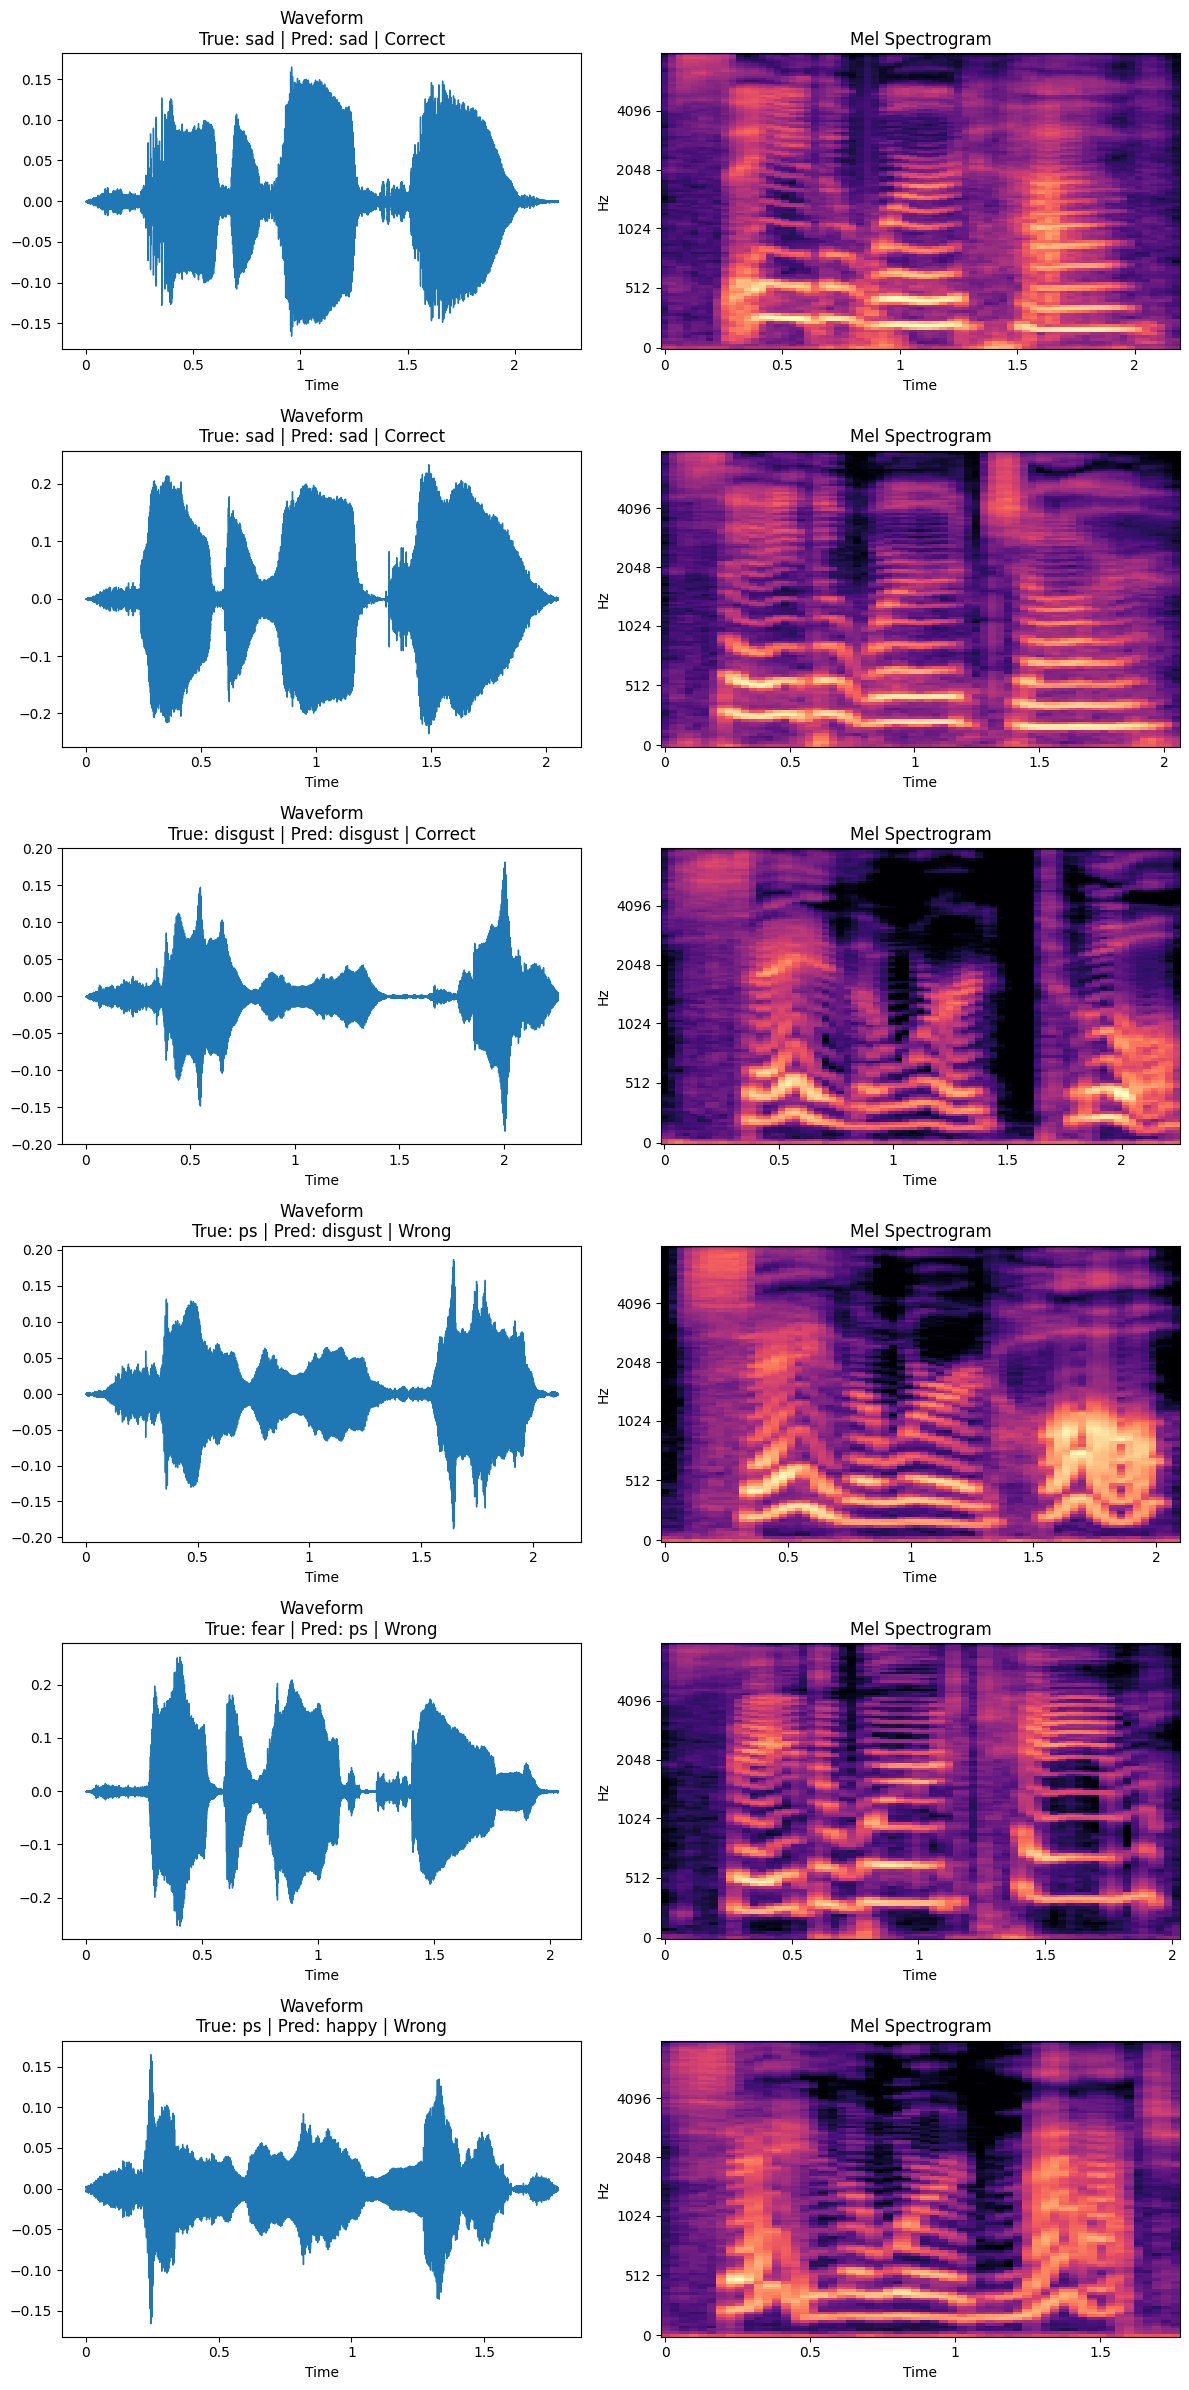

In [32]:
visualize_predictions(model, test_dataset, device, test_dataset.label_map)

In [35]:
torch.save(model, "LSTM-emotion-classifier.pt")

In [33]:
!nvidia-smi

Mon Aug  3 17:17:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P0             27W /   70W |     245MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Observation report

1. Used TESS dataset
2. Reson for choosing the dataset
  - Contains exactly 400 samples for each of its seven emotion categories, avoiding training bias.
  - Features a total of 2,800 distinct audio file utterances.
  - Uses a uniform carrier phrase ("Say the word [target]") across all recordings
3. Preprocessing and feature Extraction step
  - load_audio() - load audio file, convert it to mono and resample
  - pad_or_truncate() - make each audio file of equal length (though not impotant for LSTM)
  - normalize() - scales signal values to a uniform range, stabilizing gradient updates and accelerating convergence
  - extract_mfcc() - used MFCC as it is computationally fast (smaller size) and mimic human hearing, isolate the vocal tract shape
  - extract_feature() - the complete pipeline for single audio

  4. LSTM architecture
- Input Size (13): Uses the 13 MFCC coefficients extracted from each audio frame.
- Hidden Size (128): Provides sufficient capacity to learn temporal speech patterns without making the model overly complex.
- 2 LSTM Layers: Learns both low-level and high-level temporal dependencies in the speech sequence.
- Dropout (0.3): Reduces overfitting by randomly disabling neurons during training.
- Linear (128 -  64): Compresses the learned sequence representation into a more discriminative feature space.
- ReLU: Introduces non-linearity, allowing the model to learn more complex decision boundaries.
- Linear (64 -  7): Produces one output score for each of the seven emotion classes in the TESS dataset.
- Last Hidden State: Uses the final LSTM hidden state as a summary of the entire speech sequence for emotion classification.

5. Training Setup:

- Used Google Colaboratory with an Nvidia Tesla T4 to train and evaluate the model.

6. Evaluation Result:

- Accuracy : 0.9839
- Precision: 0.9843
- Recall   : 0.9839
- F1 Score : 0.9839

7. Observation:

- The model is so good in predicting all emotions compared to pleasent surprise (PS). It confuses that with other emotions as the tone during pleasent surprise is quite similar to other emotions.
